# ¿Es la ventana de entrenamiento demasiado larga?

## Qué responde este notebook

Jugadores y equipos cambian año con año: un receptor puede ser consistente tres o cuatro temporadas
y luego subir o bajar. Los modelos se entrenan con seis temporadas (2016-2021); si el nivel de un
jugador cambia dentro de esa ventana, los años más viejos podrían estar pesando de más.

Tres pasos:

1. Medir qué tanto se parece un jugador a sí mismo según cuántos años pasan.
2. En los modelos elegidos en [`4.4_ajuste_hiperparametros.ipynb`](4.4_ajuste_hiperparametros.ipynb),
   probar ventanas más cortas y una ponderación que da más peso a las temporadas recientes.
3. En el modelo jerárquico de [`4.7_jerarquico_touchdowns.ipynb`](4.7_jerarquico_touchdowns.ipynb),
   que usa un solo nivel por jugador para toda la ventana, probar una tendencia propia por jugador.

Cada alternativa se decide con la métrica principal en validación (2022-2023) y el intervalo
bootstrap de [`4.1_preparacion_y_metricas.ipynb`](4.1_preparacion_y_metricas.ipynb).

In [1]:
import sys
sys.path.insert(0, "../src")
import data, features, modeling, experimentos

import joblib
import numpy as np
import pandas as pd
import bambi as bmb
import arviz as az
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
import time

pd.set_option("display.width", 160)
AZUL, NARANJA, VERDE, GRIS, GRIS_CLARO = "#2a78d6", "#eb6834", "#1baf7a", "#888780", "#c3c2b7"

CONFIG_ELEGIDA = {
    "receptions": dict(max_depth=3, n_estimators=200, learning_rate=0.03),
    "receiving_yards": dict(max_depth=3, n_estimators=200, learning_rate=0.03),
    "receiving_tds": dict(objective="count:poisson", max_depth=3, n_estimators=200, learning_rate=0.08),
}

## 1. ¿El nivel de un jugador cambia con los años?

Para cada receptor con al menos 8 partidos en una temporada, se compara su nivel en la temporada `t`
contra su nivel en `t + k`, para k = 1 a 5 años. El nivel es el total de la temporada en
recepciones, yardas y touchdowns (que depende también de cuántos partidos jugó) y el promedio de
`target_share`. Solo entran los receptores que siguen con al menos 8 partidos `k` años después. Si
la correlación cae rápido, un jugador de hace
cinco años se parece poco al de hoy; si se mantiene, una ventana larga no es problema.

In [2]:
stats = data.cargar_stats_semanales(range(2016, 2026))
wr_stats = stats[stats["position"] == "WR"].copy()

por_temporada = wr_stats.groupby(["player_id", "season"]).agg(
    partidos=("week", "nunique"),
    receiving_tds=("receiving_tds", "sum"),
    receiving_yards=("receiving_yards", "sum"),
    receptions=("receptions", "sum"),
).reset_index()
por_temporada = por_temporada[por_temporada["partidos"] >= 8]

target_share_temp = wr_stats.groupby(["player_id", "season"])["target_share"].mean().reset_index()
por_temporada = por_temporada.merge(target_share_temp, on=["player_id", "season"])
print(f"jugador-temporadas con >=8 partidos: {len(por_temporada)}")

filas = []
for metrica in ["target_share", "receiving_yards", "receiving_tds", "receptions"]:
    for lag in [1, 2, 3, 4, 5]:
        a = por_temporada[["player_id", "season", metrica]]
        b = a.copy()
        b["season"] = b["season"] - lag
        cruce = a.merge(b, on=["player_id", "season"], suffixes=("_t", "_t_mas_lag"))
        if len(cruce) < 30:
            continue
        filas.append({"metrica": metrica, "lag_anios": lag, "n_pares": len(cruce),
                       "correlacion": cruce[f"{metrica}_t"].corr(cruce[f"{metrica}_t_mas_lag"])})

tabla_decadencia = pd.DataFrame(filas)
tabla_pivote = tabla_decadencia.pivot(index="metrica", columns="lag_anios", values="correlacion")
print(tabla_pivote.round(3).to_string())

jugador-temporadas con >=8 partidos: 1552
lag_anios            1      2      3      4      5
metrica                                           
receiving_tds    0.522  0.488  0.491  0.419  0.466
receiving_yards  0.717  0.639  0.589  0.554  0.505
receptions       0.724  0.642  0.575  0.530  0.494
target_share     0.799  0.709  0.683  0.649  0.575


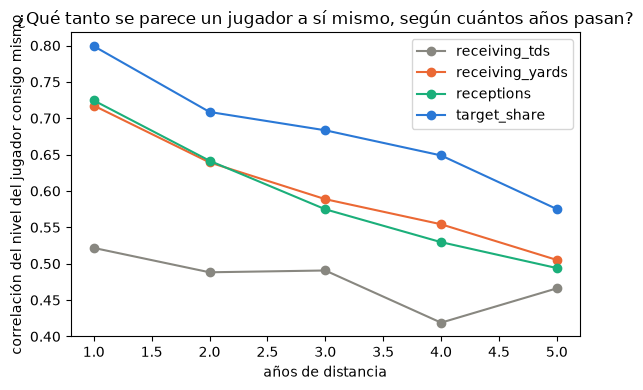

In [3]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 4))
colores = {"target_share": AZUL, "receiving_yards": NARANJA, "receptions": VERDE, "receiving_tds": GRIS}
for metrica in tabla_pivote.index:
    ax.plot(tabla_pivote.columns, tabla_pivote.loc[metrica], marker="o", label=metrica, color=colores[metrica])
ax.set_xlabel("años de distancia")
ax.set_ylabel("correlación del nivel del jugador consigo mismo")
ax.set_title("¿Qué tanto se parece un jugador a sí mismo, según cuántos años pasan?")
ax.legend()
plt.tight_layout()
plt.show()

**Lectura.** Con 1,552 temporadas de receptores con al menos 8 partidos, el nivel de un jugador sí
cambia con los años, de forma gradual y sin un corte abrupto: la correlación de `target_share`
consigo mismo baja de 0.799 a un año a 0.575 a cinco; la de recepciones, de 0.724 a 0.494, y la de
yardas, de 0.717 a 0.505. Los touchdowns son más ruidosos desde el inicio (0.522 a un año) y bajan
menos, con altibajos (0.466 a cinco). Un receptor
de hace cinco años todavía dice algo de cómo es hoy, pero bastante menos que el del año pasado.

## 2. Ventana más corta o más peso a lo reciente, en los modelos elegidos

Dos formas de que los años viejos pesen menos:

- **Ventana más corta**: entrenar solo con las últimas 5, 4 o 3 temporadas.
- **Ponderación por antigüedad**: conservar las seis temporadas, pero con peso
  `0.5 ^ (años de antigüedad / vida media)`; con vida media de 2 temporadas, 2019 pesa la mitad que
  2021 y 2017 la cuarta parte.

Se comparan contra la ventana actual con la métrica principal de cada resultado en validación. El R²
fuera de muestra se mide siempre contra la media de 2016-2021, para que las filas sean comparables.

In [4]:
wr = features.construir_tabla_modelado(range(2016, 2026))
features_arbol = features.columnas_por_modelo("arbol")
features_ridge = features.columnas_por_modelo("ridge")
train_mask, val_mask, test_mask = experimentos.dividir_temporal(wr, range(2016, 2022), [2022, 2023], [2024, 2025])

VARIANTES = {
    "2016-2021 (actual)": (2016, None),
    "2017-2021": (2017, None),
    "2018-2021": (2018, None),
    "2019-2021": (2019, None),
    "2016-2021, vida media 3": (2016, 3),
    "2016-2021, vida media 2": (2016, 2),
}

def entrenar_variante(target, inicio, vida_media):
    filas = train_mask & (wr["season"] >= inicio)
    pesos = None if vida_media is None else 0.5 ** ((2021 - wr.loc[filas, "season"]) / vida_media)
    modelo = XGBRegressor(**CONFIG_ELEGIDA[target], random_state=0, n_jobs=-1)
    modelo.fit(wr.loc[filas, features_arbol], wr.loc[filas, target], sample_weight=pesos)
    return pd.Series(np.clip(modelo.predict(wr[features_arbol]), 0, None), index=wr.index), int(filas.sum())

tablas_ventana = {}
for target in modeling.TARGETS:
    criterio = modeling.METRICA_PRINCIPAL[target]
    y = wr[target]
    media = y[train_mask].mean()
    predicciones, filas = {}, {}
    for nombre, (inicio, vida_media) in VARIANTES.items():
        pred, n = entrenar_variante(target, inicio, vida_media)
        predicciones[nombre] = pred
        val = modeling.metricas_target(target, y[val_mask], pred[val_mask], media)
        test = modeling.metricas_target(target, y[test_mask], pred[test_mask], media)
        fila = {"filas_train": n, f"val_{criterio}": val[criterio], "val_r2_oos": val["r2_oos"],
                "val_pendiente": val["pendiente_calibracion"], f"test_{criterio}": test[criterio], "test_r2_oos": test["r2_oos"]}
        if nombre != "2016-2021 (actual)":
            c = experimentos.diferencia_bootstrap(wr[val_mask], y[val_mask], pred[val_mask],
                                                  predicciones["2016-2021 (actual)"][val_mask], criterio)
            fila.update({"dif_val": c["diferencia"], "IC_inf": c["ic_inferior"], "IC_sup": c["ic_superior"],
                         "se_adopta": (not c["empate"]) and c["diferencia"] < 0})
        filas[nombre] = fila
    tablas_ventana[target] = pd.DataFrame(filas).T.infer_objects()
    print(f"--- {target} (metrica principal: {criterio})")
    print(tablas_ventana[target].to_string(float_format=lambda x: f"{x:.4f}"))
    print()

--- receptions (metrica principal: rmse)
                         filas_train  val_rmse  val_r2_oos  val_pendiente  test_rmse  test_r2_oos  dif_val  IC_inf  IC_sup se_adopta
2016-2021 (actual)        13795.0000    1.9293      0.4377         1.0494     1.8258       0.4585      NaN     NaN     NaN       NaN
2017-2021                 11509.0000    1.9234      0.4412         1.0331     1.8239       0.4596  -0.0059 -0.0128  0.0001     False
2018-2021                  9270.0000    1.9288      0.4380         1.0214     1.8279       0.4573  -0.0004 -0.0091  0.0074     False
2019-2021                  7044.0000    1.9291      0.4378         1.0135     1.8241       0.4595  -0.0002 -0.0094  0.0079     False
2016-2021, vida media 3   13795.0000    1.9257      0.4398         1.0361     1.8241       0.4595  -0.0035 -0.0080  0.0011     False
2016-2021, vida media 2   13795.0000    1.9259      0.4397         1.0243     1.8219       0.4608  -0.0033 -0.0095  0.0024     False



--- receiving_yards (metrica principal: rmse)
                         filas_train  val_rmse  val_r2_oos  val_pendiente  test_rmse  test_r2_oos  dif_val  IC_inf  IC_sup se_adopta
2016-2021 (actual)        13795.0000   29.5718      0.3624         1.0711    27.9143       0.3754      NaN     NaN     NaN       NaN
2017-2021                 11509.0000   29.5162      0.3648         1.0419    27.8818       0.3768  -0.0556 -0.1380  0.0281     False
2018-2021                  9270.0000   29.5021      0.3654         1.0462    27.9113       0.3755  -0.0697 -0.1602  0.0154     False
2019-2021                  7044.0000   29.7202      0.3560         1.0339    27.9368       0.3743   0.1484  0.0485  0.2475     False
2016-2021, vida media 3   13795.0000   29.5548      0.3632         1.0514    27.8928       0.3763  -0.0170 -0.0784  0.0447     False
2016-2021, vida media 2   13795.0000   29.5386      0.3639         1.0420    27.9589       0.3734  -0.0332 -0.1037  0.0384     False



--- receiving_tds (metrica principal: deviance_poisson)
                         filas_train  val_deviance_poisson  val_r2_oos  val_pendiente  test_deviance_poisson  test_r2_oos  dif_val  IC_inf  IC_sup se_adopta
2016-2021 (actual)        13795.0000                0.6167      0.0826         0.9604                 0.6252       0.0877      NaN     NaN     NaN       NaN
2017-2021                 11509.0000                0.6167      0.0812         0.9126                 0.6226       0.0912   0.0000 -0.0033  0.0035     False
2018-2021                  9270.0000                0.6194      0.0809         0.9048                 0.6232       0.0906   0.0028 -0.0009  0.0066     False
2019-2021                  7044.0000                0.6169      0.0838         0.8989                 0.6288       0.0828   0.0003 -0.0042  0.0049     False
2016-2021, vida media 3   13795.0000                0.6153      0.0833         0.9242                 0.6237       0.0893  -0.0013 -0.0043  0.0017     False
20

### Varias alternativas contra el mismo modelo

La tabla compara cinco variantes contra la ventana actual en cada resultado: 15 alternativas para la
misma pregunta. La columna `se_adopta` usa el intervalo de 95% de cada comparación por separado. Con
tantas alternativas alguna puede excluir el cero por azar, así que la regla de
[`4.1_preparacion_y_metricas.ipynb`](4.1_preparacion_y_metricas.ipynb) pide ajustar cada intervalo a
un nivel de 1 − 0.05 / 15 (corrección de Bonferroni). La celda siguiente recalcula, con 20,000
remuestreos porque el intervalo usa colas muy pequeñas, las variantes que la tabla marque como mejora;
si no marca ninguna, no hay nada que ajustar.

In [5]:
n_comparaciones = sum(len(tabla) - 1 for tabla in tablas_ventana.values())
nivel = 1 - 0.05 / n_comparaciones
print(f"comparaciones contra la ventana actual: {n_comparaciones}; nivel ajustado: {nivel:.4f}")
for target, tabla in tablas_ventana.items():
    for nombre in tabla.index[tabla["se_adopta"] == True]:
        pred, _ = entrenar_variante(target, *VARIANTES[nombre])
        actual, _ = entrenar_variante(target, *VARIANTES["2016-2021 (actual)"])
        c = experimentos.diferencia_bootstrap(wr[val_mask], wr.loc[val_mask, target], pred[val_mask], actual[val_mask],
                                              modeling.METRICA_PRINCIPAL[target], n_remuestreos=20000, nivel=nivel)
        print(f"{target}, {nombre}: diferencia {c['diferencia']:+.4f}, intervalo ajustado "
              f"{c['ic_inferior']:+.4f} a {c['ic_superior']:+.4f} -> {'empate' if c['empate'] else 'mejora real'}")

comparaciones contra la ventana actual: 15; nivel ajustado: 0.9967


**Lectura.** Ninguna variante mejora de forma real:

- **Yardas**: las ventanas de 5 y 4 temporadas y las dos ponderaciones quedan en empate
  (diferencias de −0.070 a −0.017 en RMSE). Recortar a 3 temporadas empeora (+0.1484, con intervalo
  de 95% de +0.0485 a +0.2475, sin ajustar; como es un empeoramiento, el ajuste no cambiaría la
  decisión): con tres temporadas se pierde más información de la que se gana en vigencia.
- **Touchdowns**: todas empatan; las diferencias de deviance van de −0.0013 a +0.0028.
- **Recepciones**: todas empatan. La que más se acerca es la ventana de 5 temporadas (−0.0059, de
  −0.0128 a +0.0001), una mejora de 0.3% del RMSE que en la prueba casi desaparece (1.8239 contra
  1.8258).

Como ninguna mejora excluye el cero con el intervalo de 95%, el ajuste por las 15 comparaciones no
cambia nada aquí.

## 3. Tendencia propia por jugador en el modelo jerárquico de touchdowns

El modelo de 4.7 tiene un nivel fijo por jugador (`1|player_id`). La alternativa directa es que
cada jugador tenga además su propia pendiente en el tiempo, `(1 + temporada | player_id)`: subiendo,
bajando o estable. Se reutilizan el modelo y los imputadores guardados por 4.7, así que solo se
ajusta el modelo nuevo. Ese archivo no se versiona: 4.7 tiene que haberse corrido antes en la misma
máquina.

In [6]:
paquete = joblib.load("../models/exploratorio/receiving_tds_jerarquico.joblib")
target = "receiving_tds"
cols_numericas = paquete["cols_numericas"]
centro_temporadas = wr.loc[train_mask, "season"].mean()

def datos_para(mascara):
    df = wr.loc[mascara, features_ridge]
    num = pd.DataFrame(paquete["imputador_num"].transform(df[cols_numericas]), index=df.index, columns=cols_numericas)
    cat = pd.DataFrame(paquete["imputador_cat"].transform(df[["anios_experiencia_bucket"]]), index=df.index,
                       columns=["anios_experiencia_bucket"])
    datos = pd.concat([num, cat], axis=1)[features_ridge]
    datos["player_id"] = wr.loc[mascara, "player_id"].astype(str).to_numpy()
    datos["season_c"] = wr.loc[mascara, "season"].to_numpy() - centro_temporadas
    return datos

datos_train = datos_para(train_mask)
datos_train[target] = wr.loc[train_mask, target].to_numpy()

modelo_nivel = bmb.Model(paquete["formula"], datos_train, family=paquete["family"])
formula_pendiente = f"{target} ~ " + " + ".join(features_ridge) + " + (1 + season_c|player_id)"
modelo_pendiente = bmb.Model(formula_pendiente, datos_train, family="negativebinomial")
t0 = time.time()
idata_pendiente = modelo_pendiente.fit(draws=500, tune=500, chains=4, cores=4, random_seed=0, progressbar=False)
print(f"tiempo de ajuste: {time.time() - t0:.0f}s")
resumen_pendiente = az.summary(idata_pendiente)
print(f"r_hat maximo: {resumen_pendiente['r_hat'].max():.4f} | parametros con r_hat > 1.01: "
      f"{(resumen_pendiente['r_hat'] > 1.01).sum()} de {len(resumen_pendiente)}")

Initializing NUTS using jitter+adapt_diag...


/usr/local/lib/python3.13/site-packages/pytensor/tensor/rewriting/elemwise.py:1004: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [alpha, Intercept, anios_experiencia, catch_rate_career_avg, depth_team, draft_pick, edad, fantasy_points_ppr_last3_avg, fantasy_points_ppr_last5_avg, fantasy_points_ppr_season_avg, receiving_10_last3_avg, receiving_16_last5_avg, receiving_20_last3_avg, receiving_air_yards_season_avg, receiving_epa_last3_avg, receiving_first_downs_career_avg, receiving_first_downs_last5_avg, receiving_tds_season_avg, receiving_yards_career_avg, receiving_yards_last3_avg, receiving_yards_season_avg, receptions_career_avg, receptions_last3_avg, receptions_last5_avg, receptions_season_avg, targets_last3_avg, targets_last5_avg, targets_season_avg, wopr_last3_avg, wopr_last5_avg, anios_experiencia_sq, anios_experiencia_bucket, 1|player_id_sigma, 1|player_id_offset, season_c|player_id_sigma, season_c|player_id_offset]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 206 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


tiempo de ajuste: 221s


r_hat maximo: 1.0225 | parametros con r_hat > 1.01: 15 de 1046


In [7]:
def predecir_mu(modelo, idata, datos):
    p = modelo.predict(idata, data=datos, kind="response_params", inplace=False, sample_new_groups=True)
    return p.posterior["mu"].mean(dim=["chain", "draw"]).to_numpy()

y = wr[target]
media = y[train_mask].mean()
pred_nivel = pd.Series(np.nan, index=wr.index)
pred_pendiente = pd.Series(np.nan, index=wr.index)
for mascara in (val_mask, test_mask):
    datos = datos_para(mascara)
    pred_nivel[mascara] = predecir_mu(modelo_nivel, paquete["idata"], datos.drop(columns="season_c"))
    pred_pendiente[mascara] = predecir_mu(modelo_pendiente, idata_pendiente, datos)

filas = {}
for nombre, pred in (("XGBoost elegido", entrenar_variante(target, 2016, None)[0]),
                     ("jerárquico, nivel por jugador (4.7)", pred_nivel),
                     ("jerárquico, nivel + tendencia por jugador", pred_pendiente)):
    fila = {}
    for parte, mascara in (("val", val_mask), ("test", test_mask)):
        m = modeling.metricas_target(target, y[mascara], pred[mascara], media)
        fila.update({f"{parte}_{k}": m[k] for k in ("deviance_poisson", "d2_oos", "r2_oos", "pendiente_calibracion")})
    filas[nombre] = fila
c = experimentos.diferencia_bootstrap(wr[val_mask], y[val_mask], pred_pendiente[val_mask], pred_nivel[val_mask], "deviance_poisson")
print(f"tendencia menos nivel, deviance de validacion = {c['diferencia']:+.4f} "
      f"(IC 95%: {c['ic_inferior']:+.4f} a {c['ic_superior']:+.4f}) -> "
      f"{'empate' if c['empate'] else ('mejora real' if c['diferencia'] < 0 else 'empeora')}")
pd.DataFrame(filas).T.round(4)

/tmp/ipykernel_7/4101694184.py:2: FutureWarning: 'sample_new_groups' is deprecated and will be removed in a future version. New groups will be handled automatically.
  p = modelo.predict(idata, data=datos, kind="response_params", inplace=False, sample_new_groups=True)


/tmp/ipykernel_7/4101694184.py:2: FutureWarning: 'sample_new_groups' is deprecated and will be removed in a future version. New groups will be handled automatically.
  p = modelo.predict(idata, data=datos, kind="response_params", inplace=False, sample_new_groups=True)


/tmp/ipykernel_7/4101694184.py:2: FutureWarning: 'sample_new_groups' is deprecated and will be removed in a future version. New groups will be handled automatically.
  p = modelo.predict(idata, data=datos, kind="response_params", inplace=False, sample_new_groups=True)


/tmp/ipykernel_7/4101694184.py:2: FutureWarning: 'sample_new_groups' is deprecated and will be removed in a future version. New groups will be handled automatically.
  p = modelo.predict(idata, data=datos, kind="response_params", inplace=False, sample_new_groups=True)


tendencia menos nivel, deviance de validacion = +0.0023 (IC 95%: +0.0009 a +0.0036) -> empeora


,val_deviance_poisson,val_d2_oos,val_r2_oos,val_pendiente_calibracion,test_deviance_poisson,test_d2_oos,test_r2_oos,test_pendiente_calibracion
XGBoost elegido,0.6167,0.1223,0.0826,0.9604,0.6252,0.1355,0.0877,1.0104
"jerárquico, nivel por jugador (4.7)",0.6296,0.1039,0.0675,0.8022,0.6390,0.1165,0.0744,0.8393
"jerárquico, nivel + tendencia por jugador",0.6319,0.1006,0.0631,0.7733,0.6388,0.1168,0.0713,0.7839


**Lectura.** El modelo con tendencia por jugador tiene 1,046 parámetros, casi el doble que los 540
de 4.7; 15 de ellos con
`r_hat` sobre 1.01 (máximo 1.0225). Es peor que el de solo nivel por jugador: +0.0023 de deviance en
validación, con intervalo de +0.0009 a +0.0036, y su calibración también empeora (pendiente de 0.773
contra 0.802). Los dos quedan detrás del XGBoost elegido (0.6167). Una explicación posible es que la
tendencia de cada jugador, estimada con 2016-2021, se extrapola uno o dos años hacia validación, y
muchos receptores tienen pocas temporadas en entrenamiento para estimarla (Chase, por ejemplo, solo
una; ver 4.7).

## Cierre

El nivel de un receptor cambia con los años, de forma gradual, pero ninguna de las correcciones
probadas mejora los modelos:

| Alternativa | Resultado |
|---|---|
| Ventanas de 5 o 4 temporadas | Empate en los tres resultados |
| Ventana de 3 temporadas | Empate en recepciones y touchdowns; peor en yardas (+0.1484 de RMSE) |
| Más peso a las temporadas recientes | Empate en los tres resultados |
| Tendencia por jugador en el jerárquico de touchdowns | Peor que el nivel fijo (+0.0023 de deviance) |

Una explicación posible, que aquí no se prueba, es que las variables rezagadas (`_last3_avg`,
`_last5_avg`, `_season_avg`) ya siguen la forma reciente de cada receptor, así que los años viejos no
estorban. Se conservan todas las
temporadas sin ponderar: 2016-2021 en la etapa de modelado y 2016-2025 en el modelo final.

Anterior: [`4.8_jerarquico_recepciones_yardas.ipynb`](4.8_jerarquico_recepciones_yardas.ipynb) ·
Siguiente etapa: [`5.1_estabilidad_temporal.ipynb`](5.1_estabilidad_temporal.ipynb)